# Econ 390 - Lecture 22: OLS
Today we will be looking at examining the relationships between variables using visualizations and Ordinary Least Squares in Python. You can find the relevant info from [McKinney](https://wesmckinney.com/book/modeling#modeling-statsmodels) and a similar but different package in [Turrell](https://aeturrell.github.io/coding-for-economists/econmt-regression.html#regression-basics).

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt 

## Visualization

In [2]:
# Load seaborn dataset
taxi = sns.load_dataset("taxis")
taxi

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


NameError: name 'tips' is not defined

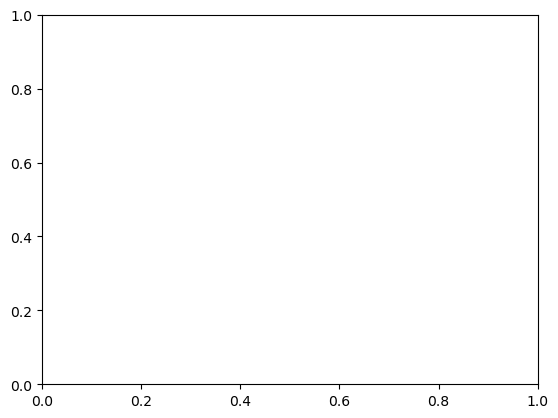

In [3]:
# Scatterplot of fare and tip
fig, ax = plt.subplots()
ax.scatter(taxi["fare"],tips["tip"]);

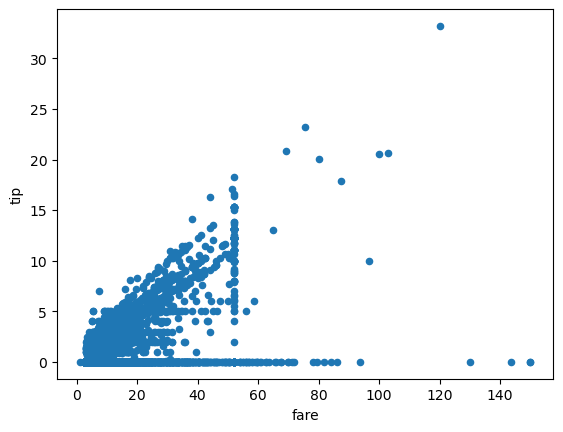

In [4]:
# Basic plot
taxi.plot.scatter("fare","tip");

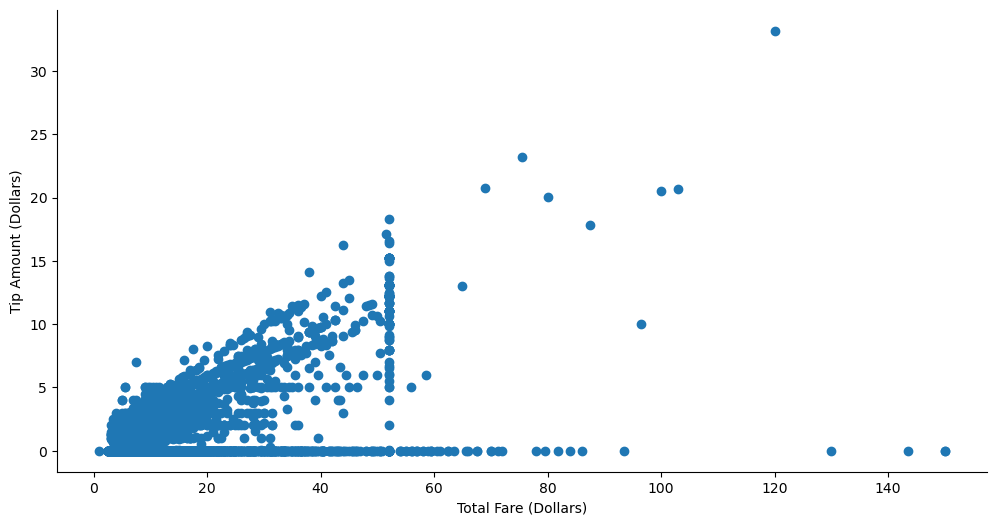

In [5]:
# Customizing
fig, ax = plt.subplots(figsize = (12, 6))
ax.scatter(taxi["fare"],taxi["tip"])
ax.set(xlabel = "Total Fare (Dollars)", ylabel = "Tip Amount (Dollars)")
sns.despine(ax=ax)
plt.show()

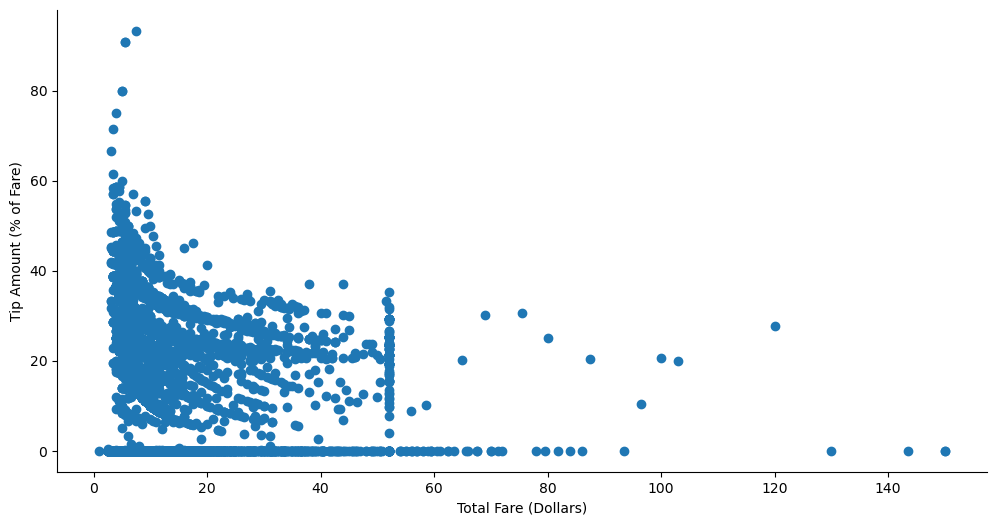

In [6]:
# Convert tip into a percentage of fair and plot that
taxi['tip_pct'] = 100 * taxi["tip"] / taxi["fare"]

fig, ax = plt.subplots(figsize=(12,6))
ax.scatter(taxi['fare'],taxi['tip_pct'])
ax.set(xlabel='Total Fare (Dollars)', ylabel='Tip Amount (% of Fare)')
sns.despine()
plt.show()

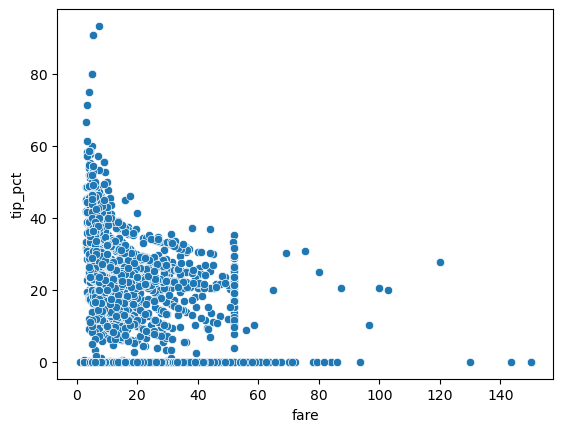

In [7]:
# Seaborn default scatterplot
sns.scatterplot(x="fare", y = "tip_pct", data = taxi);

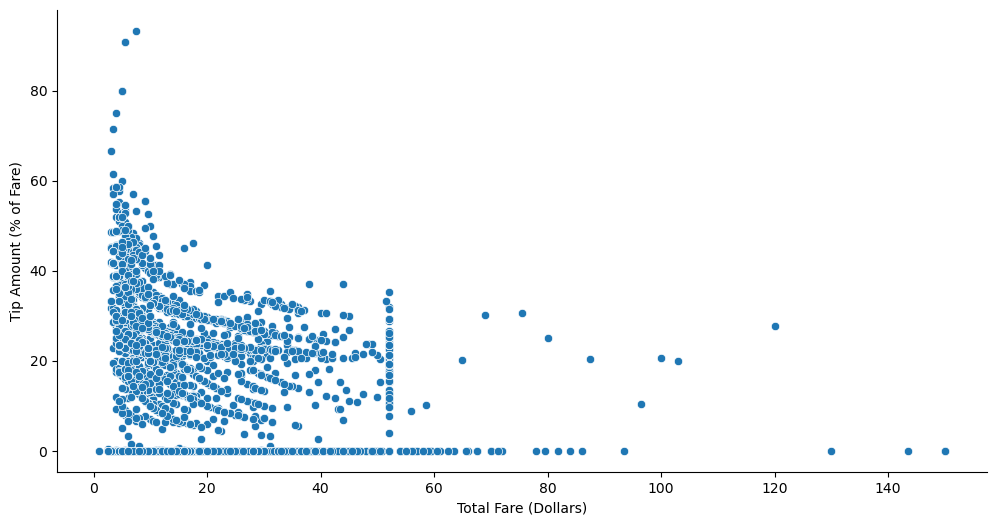

In [8]:
# Seaborn with customization
fig, ax = plt.subplots(figsize=(12,6)) 

ax = sns.scatterplot(x='fare', y='tip_pct', data=taxi)

ax.set(xlabel='Total Fare (Dollars)', ylabel='Tip Amount (% of Fare)')
sns.despine()
plt.show()

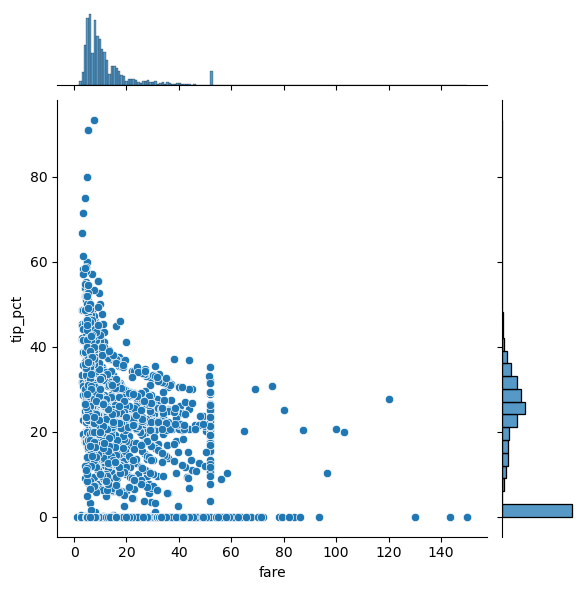

In [9]:
# Jointplot
sns.jointplot(x='fare', y='tip_pct', data=taxi);

AttributeError: 'JointGrid' object has no attribute 'axes'

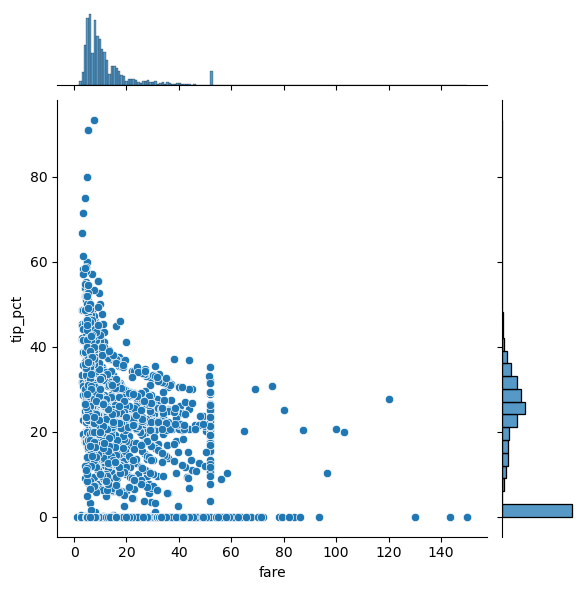

In [10]:
# Customize Joint Plot?
ax = sns.jointplot(x='fare', y='tip_pct', data=taxi)
ax.set(xlabel='Total Fare (Dollars)', ylabel='Tip Amount (% of Fare)')
sns.despine()
plt.show()

In [11]:
# What are they
print(type(ax))
print(type(ax.ax_joint))

<class 'seaborn.axisgrid.JointGrid'>
<class 'matplotlib.axes._axes.Axes'>


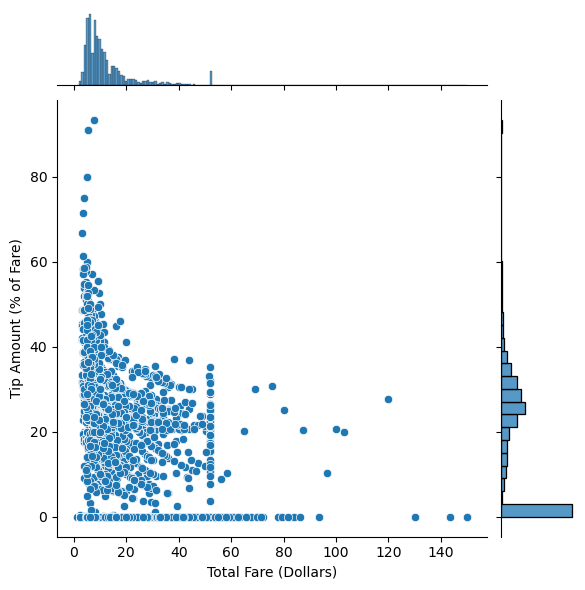

In [12]:
# Use .set on ax_joint
ax = sns.jointplot(x='fare', y='tip_pct', data=taxi)
ax.ax_joint.set(xlabel='Total Fare (Dollars)', ylabel='Tip Amount (% of Fare)');

## Practice - Visualization
1. Produce a similar joint plot but for payment instead of total bill.
2. With this in mind, remake the plot above but getting rid of the data that doesn't make sense to include. Hint: Subset the data in the jointplot function

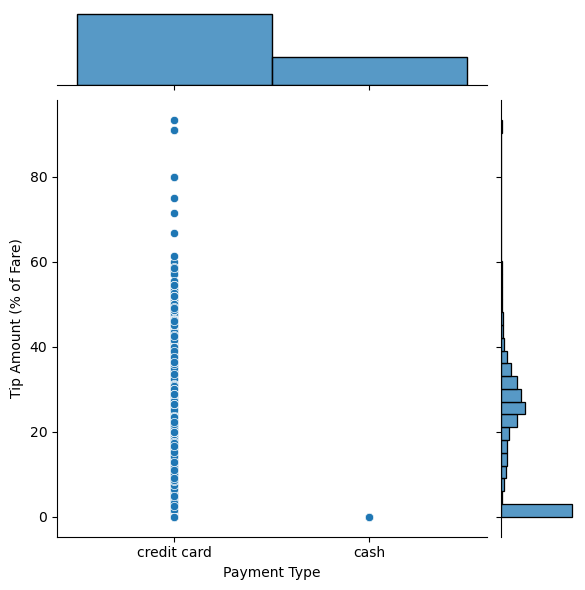

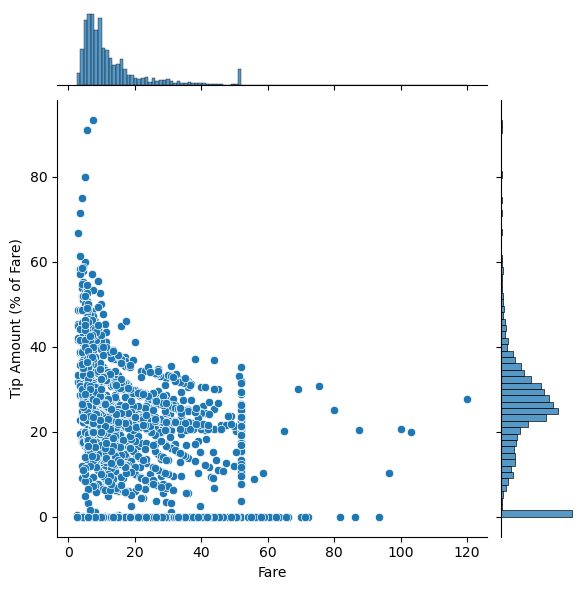

In [13]:
# Results:
ax = sns.jointplot(x='payment', y='tip_pct', data=taxi)
ax.ax_joint.set(xlabel='Payment Type', ylabel='Tip Amount (% of Fare)');

ax = sns.jointplot(x='fare', y='tip_pct', data=taxi[taxi["payment"] != "cash"])
ax.ax_joint.set(xlabel='Fare', ylabel='Tip Amount (% of Fare)');

## Regression Analysis

In [14]:
# Update dataset to drop cash
taxi_noCash = taxi[taxi["payment"] != "cash"]

In [15]:
# Correlations
taxi_noCash.corr(numeric_only = True)

,passengers,distance,fare,tip,tolls,total,tip_pct
passengers,1.000000,-0.008417,-0.014921,0.033359,-0.015673,-0.002453,0.059385
distance,-0.008417,1.000000,0.911750,0.548785,0.639564,0.898474,-0.308866
fare,-0.014921,0.911750,1.000000,0.608724,0.603518,0.975890,-0.339081
tip,0.033359,0.548785,0.608724,1.000000,0.499962,0.745239,0.320342
tolls,-0.015673,0.639564,0.603518,0.499962,1.000000,0.684531,-0.092381
total,-0.002453,0.898474,0.975890,0.745239,0.684531,1.000000,-0.197170
tip_pct,0.059385,-0.308866,-0.339081,0.320342,-0.092381,-0.197170,1.000000


In [16]:
# New package!
import statsmodels.formula.api as smf 

In [17]:
# Regression
reg_results = smf.ols("tip_pct ~ fare", data = taxi_noCash).fit()
reg_results

In [18]:
# Print the results
print(reg_results.summary())

                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     600.1
Date:                Sun, 05 Apr 2026   Prob (F-statistic):          1.07e-124
Time:                        18:12:36   Log-Likelihood:                -17698.
No. Observations:                4621   AIC:                         3.540e+04
Df Residuals:                    4619   BIC:                         3.541e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     28.2847      0.253    111.659      0.0

In [19]:
# Bias correct the variances
reg_results = smf.ols("tip_pct ~ fare", data = taxi_noCash).fit(cov_type="HC1")
print(reg_results.summary())

                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     385.3
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.84e-82
Time:                        18:12:36   Log-Likelihood:                -17698.
No. Observations:                4621   AIC:                         3.540e+04
Df Residuals:                    4619   BIC:                         3.541e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     28.2847      0.287     98.523      0.0

In [20]:
# Print results
print('Parameters: ', reg_results.params, '\n')
print('Standard Errors: ', reg_results.bse, '\n')
print('R^2: ', reg_results.rsquared)

Parameters:  Intercept    28.284693
fare         -0.345767
dtype: float64 

Standard Errors:  Intercept    0.287088
fare         0.017615
dtype: float64 

R^2:  0.11497593631204905


In [21]:
# Add fitted values to the DataFrame
taxi_noCash["fitted_values"] = reg_results.fittedvalues
taxi_noCash

C:\Users\micha\AppData\Local\Temp\ipykernel_16192\1136982121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  taxi_noCash["fitted_values"] = reg_results.fittedvalues


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,tip_pct,fitted_values
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,30.714286,25.864326
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,31.466667,25.691442
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,22.777778,18.948990
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,12.222222,25.172792
5,2019-03-11 10:37:23,2019-03-11 10:47:31,1,0.49,7.5,2.16,0.0,12.96,yellow,credit card,Times Sq/Theatre District,Midtown East,Manhattan,Manhattan,28.800000,25.691442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6426,2019-03-28 08:04:47,2019-03-28 08:07:46,1,0.71,4.5,0.50,0.0,5.80,green,credit card,Central Park,Upper West Side North,Manhattan,Manhattan,11.111111,26.728743
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,23.555556,26.728743
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,0.000000,8.230219
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,0.000000,26.210092


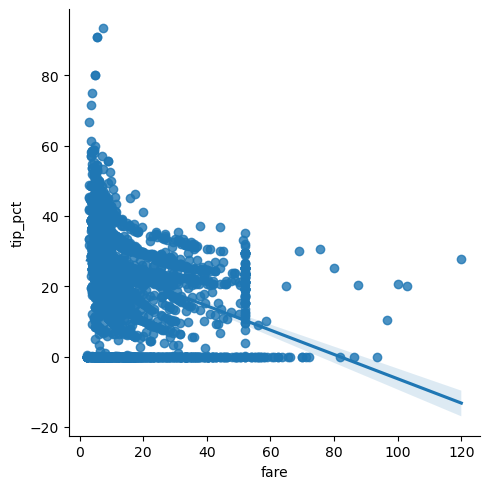

In [22]:
# lmplot
sns.lmplot(x="fare", y="tip_pct", data=taxi_noCash);

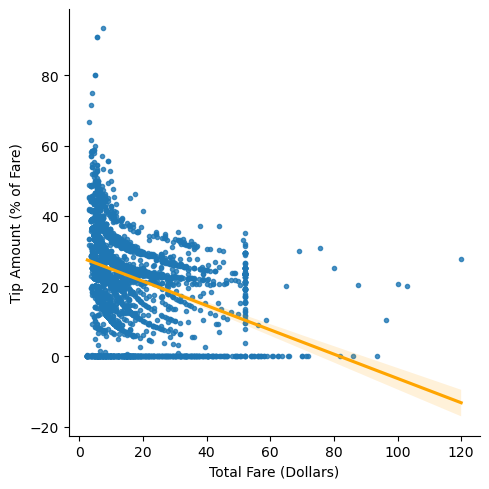

In [23]:
# lmplot customized
ax = sns.lmplot(x="fare", y="tip_pct", data=taxi_noCash, markers='.', line_kws={'color': 'orange'})
ax.set(xlabel='Total Fare (Dollars)', ylabel='Tip Amount (% of Fare)',)
sns.despine()
plt.show()

In [24]:
# Another regression
reg_results2 = smf.ols('tip_pct ~ fare + passengers', data=taxi_noCash).fit(cov_type='HC1')
print(reg_results2.summary())

                            OLS Regression Results                            
Dep. Variable:                tip_pct   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     206.3
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.47e-86
Time:                        18:12:38   Log-Likelihood:                -17690.
No. Observations:                4621   AIC:                         3.539e+04
Df Residuals:                    4618   BIC:                         3.541e+04
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     27.4592      0.355     77.281      0.0

In [25]:
# New function
from statsmodels.iolib.summary2 import summary_col

In [26]:
# Prettier printing
model1 = smf.ols('tip_pct ~ fare', data=taxi_noCash).fit(cov_type='HC1')
model2 = smf.ols('tip_pct ~ fare + passengers', data=taxi_noCash).fit(cov_type='HC1')

print(summary_col([model1, model2]))


               tip_pct I tip_pct II
-----------------------------------
Intercept      28.2847   27.4592   
               (0.2871)  (0.3553)  
fare           -0.3458   -0.3449   
               (0.0176)  (0.0175)  
passengers               0.5307    
                         (0.1246)  
R-squared      0.1150    0.1179    
R-squared Adj. 0.1148    0.1175    
Standard errors in parentheses.


In [27]:
# Options
print(summary_col([model1,model2], stars=True, float_format='%0.2f',
                  regressor_order=['Intercept','fare','passengers'],
                  model_names=['(1)','(2)']))


                 (1)      (2)   
--------------------------------
Intercept      28.28*** 27.46***
               (0.29)   (0.36)  
fare           -0.35*** -0.34***
               (0.02)   (0.02)  
passengers              0.53*** 
                        (0.12)  
R-squared      0.11     0.12    
R-squared Adj. 0.11     0.12    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


## Practice - Regression Analysis
1. The results for a linear relationship between tip_pct and fare looks pretty bad. What if it's quadratic? How do we add that? Hint: There are multiple ways of doing this.
2. Make a nice regression table using summary_col comparing the linear and the quadratic models
3. Now, how can we get that onto the lmplot? Hint: Check out the "order" argument. What does order mean in the context of equations?


                 (1)      (2)   
--------------------------------
Intercept      28.28*** 31.82***
               (0.29)   (0.45)  
fare           -0.35*** -0.79***
               (0.02)   (0.05)  
I(fare ** 2)            0.01*** 
                        (0.00)  
R-squared      0.11     0.15    
R-squared Adj. 0.11     0.15    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


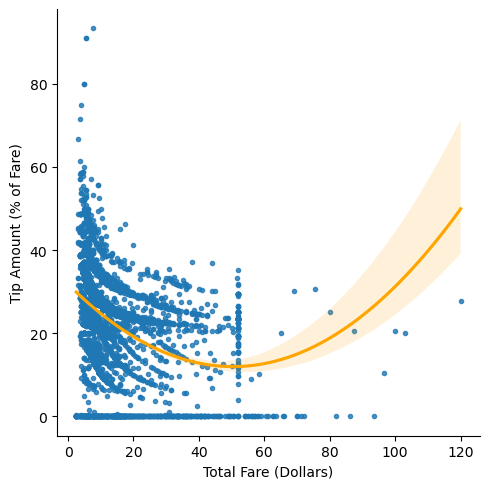

In [28]:
# Results:

model1 = smf.ols('tip_pct ~ fare', data=taxi_noCash).fit(cov_type='HC1')
model2 = smf.ols('tip_pct ~ fare + I(fare**2)', data=taxi_noCash).fit(cov_type='HC1')

print(summary_col([model1,model2], stars=True, float_format='%0.2f',
                  regressor_order=['Intercept','fare'],
                  model_names=['(1)','(2)']))

ax = sns.lmplot(x="fare", y="tip_pct", data=taxi_noCash, markers='.', line_kws={'color': 'orange'}, order = 2)
ax.set(xlabel='Total Fare (Dollars)', ylabel='Tip Amount (% of Fare)',)
sns.despine()
plt.show()